# Supervisor Agent

In [1]:
!pip install langgraph langsmith langchain_classic langchain_community langchain_groq langchain_core pydantic chromadb langchain-tavily langchain_huggingface youtube_search wikipedia httpx langchain_google_genai streamlit transformers yfinance langchain_openrouter typing-extensions langchain-text-splitters langchain-experimental

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 139.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 102.3 MB/s eta 0:00:00
   ━━━━

In [2]:
import os
from google.colab import userdata
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY').strip()

os.environ["TAVILY_API_KEY"]= userdata.get("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]= userdata.get("SERPER_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [61]:
# from langchain_groq import ChatGroq
# llm=ChatGroq(model_name="llama-3.3-70b-versatile")

from langchain_openrouter import ChatOpenRouter

llm = ChatOpenRouter(
    model="openrouter/free",
)

In [62]:
llm.invoke("hi")

AIMessage(content='Hello! 👋 How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user sent "hi". That\'s a simple greeting. I should respond in a friendly and open-ended way to encourage them to share more if they need help. Let me keep it warm and inviting. Maybe add an emoji to make it feel welcoming. No need to overcomplicate it—just a polite reply that leaves the ball in their court. Yeah, "Hello! 👋 How can I assist you today?" sounds good. It\'s standard but effective. Let me make sure it\'s not too robotic. Adding the wave emoji adds a touch of warmth. Alright, that should work.\n\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'Okay, the user sent "hi". That\'s a simple greeting. I should respond in a friendly and open-ended way to encourage them to share more if they need help. Let me keep it warm and inviting. Maybe add an emoji to make it feel welcoming. No need to overcomplicate it—just a polite reply 

In [63]:
from typing import Annotated
from typing import Literal
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END, StateGraph, START
from langgraph.types import Command
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent

In [64]:
llm.invoke("hi").content

'Hello! How can I assist you today?'

In [65]:
def clean_text(text):
  import re
  clean_text = re.sub(r"<think>.*?</think>\s*", "", text, flags=re.DOTALL)
  return clean_text

In [66]:
response = llm.invoke("hi")

In [67]:
response.content

'Hello! How can I help you today?'

In [68]:
clean_text(response.content)

'Hello! How can I help you today?'

In [69]:
tavily_tool = TavilySearchResults()

In [70]:
tavily_tool.invoke("What is a GDP?")

[{'title': 'Gross domestic product - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/Gross_domestic_product',
  'content': 'Gross domestic product (GDP) is a monetary measure of the total market value of all of the final goods and services which are produced and rendered during a specific period of time (usually a year) by a country or countries. GDP is often used to measure the economic activity of a country or region. The major components of GDP are consumption, government spending, net exports (exports minus imports), and investment. Changing any of these factors can increase the size of the economy. For example, population growth through mass immigration can raise consumption and demand for public services, thereby contributing to GDP growth. However, GDP is not a measure of overall standard of living or well-being, as it does not account for how income is distributed among the population. A country may [...] GDP is a product produced within a country\'s borders; GNI is product

In [71]:
code = """
x = 5
y = x * 2
print(y)
"""

In [72]:
repl = PythonREPL()

In [73]:
repl.run(code)

'10\n'

In [74]:
@tool
def pythonprogramming_repl_tool(
    code: Annotated[str, "The python programming code to execute to generate your chart."]):

  """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""

  try:
    result = repl.run(code)
  except Exception as e:
    return f"Failed to execute. Error: {repr(e)}"

  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
  return result_str

<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
/tmp/ipykernel_7538/3622280134.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
/tmp/ipykernel_7538/3622280134.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [75]:
print(pythonprogramming_repl_tool.invoke(code))

Successfully executed:
\`\`\`python

x = 5
y = x * 2
print(y)

\`\`\`
Stdout: 10



In [76]:
members = ["researcher", "coder"]

In [77]:
options = members + ["FINISH"]

In [78]:
options

['researcher', 'coder', 'FINISH']

In [79]:
class Router(TypedDict):
  """Worker to route to next. If no workers needed, route to FINISH."""
  next: Literal['researcher', 'coder', 'FINISH']

In [80]:
class State(MessagesState):
  next: str

In [81]:
system_prompt = f"""
You are a supervisor, tasked with managing a conversation between the following workers: {members}.
Given the following user request, respond with the worker to act next.
Each worker will perform a task and respond with their results and status.
When finished, respond with FINISH.
"""

In [82]:
[{"role": "system", "content": system_prompt},]

[{'role': 'system',
  'content': "\nYou are a supervisor, tasked with managing a conversation between the following workers: ['researcher', 'coder'].\nGiven the following user request, respond with the worker to act next.\nEach worker will perform a task and respond with their results and status.\nWhen finished, respond with FINISH.\n"}]

In [83]:
state = {"next": ["hi"]}

In [84]:
state["next"]

['hi']

In [85]:
[{"role": "system", "content": system_prompt},] + state["next"]

[{'role': 'system',
  'content': "\nYou are a supervisor, tasked with managing a conversation between the following workers: ['researcher', 'coder'].\nGiven the following user request, respond with the worker to act next.\nEach worker will perform a task and respond with their results and status.\nWhen finished, respond with FINISH.\n"},
 'hi']

In [86]:
def supervisor_node(state: State) -> Command[Literal["researcher", "coder", "__end__"]]:

  messages = [{"role": "system", "content": system_prompt},] + state["messages"]

  response = llm.with_structured_output(Router).invoke(messages)

  goto = response['next']

  print("below my goto**********************************")

  print(goto)

  if goto == "FINISH":
    goto = END

  return Command(goto=goto, update={"next": goto})

In [87]:
def research_node(state: State) -> Command[Literal["supervisor"]]:

  research_agent = create_react_agent(llm, tools=[tavily_tool], prompt="You are a researcher. DO NOT do any math.")

  result = research_agent.invoke(state)

  return Command(
      update= {
          "messages": [
              HumanMessage(content=result["messages"][-1].content, name="researcher")
          ]
      },
      goto = "supervisor",
  )

In [88]:
def code_node(state: State) -> Command[Literal["supervisor"]]:

  code_agent = create_react_agent(llm, tools=[pythonprogramming_repl_tool])

  result = code_agent.invoke(state)

  return Command(
      update = {
          "messages": [
              HumanMessage(content=result["messages"][-1].content, name="coder")
          ]
      },
      goto = "supervisor",

  )

In [89]:
graph = StateGraph(State)

In [90]:
graph.add_node("supervisor", supervisor_node)

In [91]:
graph.add_node("researcher", research_node)

In [92]:
graph.add_node("coder", code_node)

In [93]:
graph.add_edge(START, "supervisor")

In [94]:
app=graph.compile()

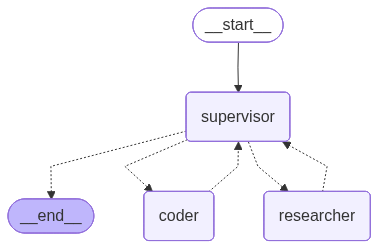

In [95]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))

In [96]:
# With the graph created, we can now invoke it and see how it performs!
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True):
  print(s)
  print("----")


below my goto**********************************
researcher
((), {'supervisor': {'next': 'researcher'}})
----


/tmp/ipykernel_7538/3008068590.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[tavily_tool], prompt="You are a researcher. DO NOT do any math.")


(('researcher:26baab95-ca47-4431-dedc-cffec5422d82',), {'agent': {'messages': [AIMessage(content='The square root of 42 is approximately 6.4807.\n\nPer your request, no further calculations or mathematical derivation are included.', additional_kwargs={'reasoning_content': '\n\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': '\n\n'}]}, response_metadata={'model_name': 'nex-agi/nex-n2-pro:free', 'id': 'gen-1781386241-bcov2IHw7fNEJ5UgKk5e', 'created': 1781386241, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'upstream_inference_completions_cost': 0.0, 'upstream_inference_prompt_cost': 0.0, 'upstream_inference_cost': 0.0}}, id='lc_run--019ec2e4-e534-7d03-84f1-3fd6f7939480-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 337, 'output_tokens': 35, 'total_tokens': 372, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'outpu

/tmp/ipykernel_7538/3008068590.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[tavily_tool], prompt="You are a researcher. DO NOT do any math.")


(('researcher:af129152-d4d2-010f-9950-18bf3ae9ebd6',), {'agent': {'messages': [AIMessage(content='\n\nThe squareroot of 42 is approximately **6.4807**. This is an approximate value, as √42 is an irrational number.\n', additional_kwargs={'reasoning_content': "Okay, the user asked for the square root of 42. I need to provide the answer. Since they mentioned not to do any math, I should just state the result. The tools available are for searching, but since the answer is already given as 6.4807, I don't need to use the search function. I'll present that number and note that it's approximate. Let me check if there's any other step needed. Nope, just confirm the answer and maybe mention that it's an approximation. Yep, that's all.\n", 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': "Okay, the user asked for the square root of 42. I need to provide the answer. Since they mentioned not to do any math, I should just state the result. The tools availabl

In [97]:
app.invoke({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True)


below my goto**********************************
coder


/tmp/ipykernel_7538/3004154098.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent = create_react_agent(llm, tools=[pythonprogramming_repl_tool])


TypeError: 'NoneType' object is not subscriptable

In [98]:
app.invoke({"messages": [("user", "What is an efficient Python code to get prime numbers?")]}, subgraphs=True)


below my goto**********************************
researcher


/tmp/ipykernel_7538/3008068590.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[tavily_tool], prompt="You are a researcher. DO NOT do any math.")


below my goto**********************************
researcher


/tmp/ipykernel_7538/3008068590.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[tavily_tool], prompt="You are a researcher. DO NOT do any math.")


below my goto**********************************
FINISH


{'messages': [HumanMessage(content='What is an efficient Python code to get prime numbers?', additional_kwargs={}, response_metadata={}, id='046c56b7-78f5-4a0b-ae61-bbd4ce98a880'),
  HumanMessage(content='Below is a compact, efficient implementation of the classic **Sieve of Eratosthenes** in Python.  \nThe sieve runs in **O(n\u202flog\u202flog\u202fn)** time and uses **O(n)** additional memory, which is about as fast as you can get for generating all primes up to a given limit.\n\n```python\ndef sieve(limit: int) -> list[int]:\n    """\n    Return a list of all prime numbers <= limit using the Sieve of Eratosthenes.\n\n    Parameters\n    ----------\n    limit : int\n        Upper bound of the range to search for primes (inclusive).\n\n    Returns\n    -------\n    list[int]\n        All prime numbers up to `limit`.\n    """\n    if limit < 2:\n        return []                         # no primes below 2\n\n    # Boolean array where index i indicates "i is still considered prime"\n  